In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## BARRAS PAREADAS

Um gráfico de barras simples é ideal para fazer comparações entre categorias, como comparar populações de diferentes países. Se eu quiser mostrar comparações não apenas entre países, mas também dentro deles, o gráfico de barras pareadas é uma boa opção. Esse tipo de gráfico é familiar para a maioria dos leitores e fácil de ler; além disso, a linha de base compartilhada facilita a realização de comparações.

Digamos que queiramos mostrar o número de homens e mulheres em cada país da nossa amostra. Um gráfico de barras pareadas nos permite fazer isso.

Observe que o gráfico de barras pareadas direciona a atenção do leitor não apenas para os níveis, mas também para a diferença. Se for importante que os leitores vejam ambos, esta é uma boa opção.

Mas, se o nosso objetivo é fazer com que o leitor foque apenas na diferença entre os dois valores dentro de cada categoria, essa não é a maneira mais direta de fazê-lo, pois estamos pedindo que ele compare a diferença de comprimentos. Em vez disso, poderíamos simplesmente mostrar a diferença entre os dois valores em uma única barra, como a que aparece abaixo.

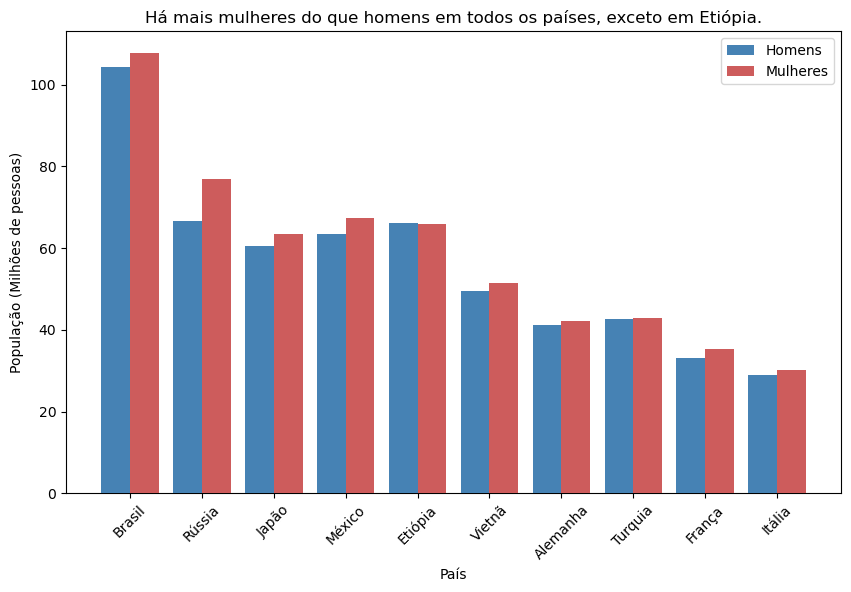

In [2]:
# Carregar os dados de população por sexo (números usam "." como separador de milhar)
data_sexo = pd.read_csv('../Data/populao-por-sexo-2024---world-bank.csv', thousands='.')

# Identificar os países em que há mais homens do que mulheres
paises_excecao = data_sexo[data_sexo['Pop. Masculina'] > data_sexo['Pop. Feminina']]['País'].tolist()

# Posições das barras pareadas: uma barra para cada sexo, lado a lado por país
posicoes = np.arange(len(data_sexo))
largura_barra = 0.4

# Criar o gráfico de barras pareadas
plt.figure(figsize=(10, 6))
plt.bar(posicoes - largura_barra / 2, data_sexo['Pop. Masculina'], width=largura_barra,
        color='steelblue', zorder=3, label='Homens')
plt.bar(posicoes + largura_barra / 2, data_sexo['Pop. Feminina'], width=largura_barra,
        color='indianred', zorder=3, label='Mulheres')

# Adicionar título e rótulos dos eixos
plt.title(f'Há mais mulheres do que homens em todos os países, exceto em {", ".join(paises_excecao)}.')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Posicionar os rótulos dos países no centro de cada par de barras
plt.xticks(posicoes, data_sexo['País'], rotation=45)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

plt.legend()

# Mostrar o gráfico
plt.show()

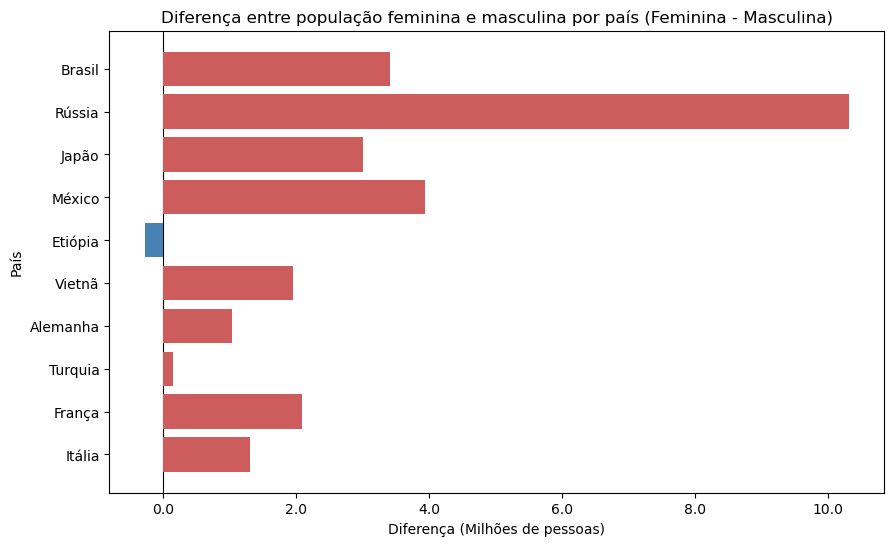

In [3]:
# Calcular a diferença entre população feminina e masculina por país
diferenca = data_sexo['Pop. Feminina'] - data_sexo['Pop. Masculina']
cores_diferenca = ['indianred' if d >= 0 else 'steelblue' for d in diferenca]

# Criar o gráfico de barras horizontais da diferença
plt.figure(figsize=(10, 6))
plt.barh(data_sexo['País'], diferenca, color=cores_diferenca, zorder=3)
plt.gca().invert_yaxis()

# Adicionar título e rótulos dos eixos
plt.title('Diferença entre população feminina e masculina por país (Feminina - Masculina)')
plt.xlabel('Diferença (Milhões de pessoas)')
plt.ylabel('País')

# Linha de referência no zero
plt.axvline(x=0, color='black', linewidth=0.8, zorder=2)

# Formatar o eixo x para mostrar em escala de 10^6 sem decimais
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}'))

# Mostrar o gráfico
plt.show()

Nos casos em que você deseja que o leitor visualize o nível e a diferença, pode ser necessário utilizar um tipo de gráfico totalmente diferente. Eu prefiro o gráfico de coordenadas paralelas (veja a página 263), o gráfico de inclinação (para dados que variam ao longo do tempo; veja a página 150) e o gráfico de pontos (veja a página 97). Lembre-se de perguntar a si mesmo: qual é o objetivo deste gráfico? Essa pergunta o guiará para a melhor maneira de visualizar seus dados.

Outra aplicação do gráfico de barras pareadas é mostrar mudanças ao longo do tempo. E, embora o termo "pareadas" conste no título, esses gráficos podem apresentar mais de dois valores. O gráfico abaixo, por exemplo, mostra a população de cinco de nossos países entre 2014 e 2018. Isso permite ao leitor analisar a variação populacional dentro de cada país e as diferenças entre eles.

Os padrões presentes em seus dados também podem orientar a escolha do tipo de gráfico. Se os valores apresentarem um declínio uniforme ao longo dos anos para todas as categorias, um gráfico de barras pareadas pode ser adequado. No entanto, se os valores oscilarem ao longo do tempo, um gráfico de linhas ou um gráfico de ciclos pode facilitar as comparações temporais, tanto dentro de cada grupo quanto entre eles.

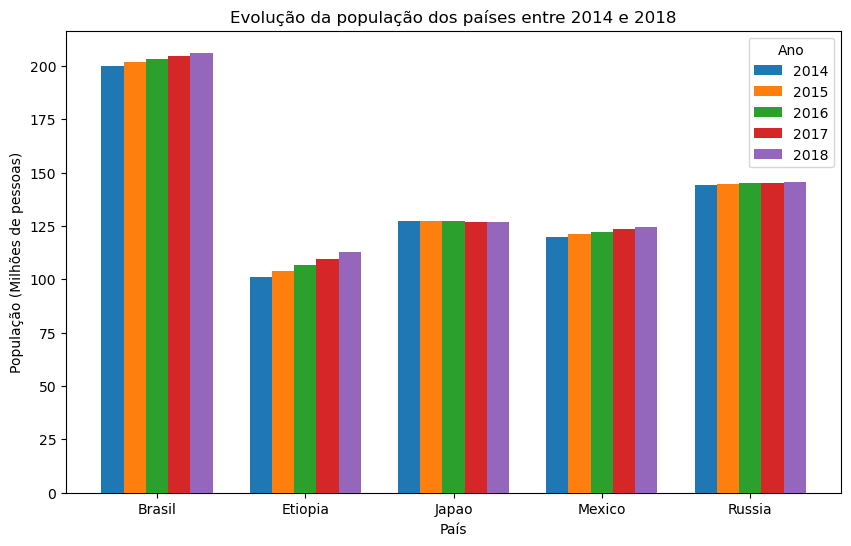

In [4]:
# Carregar os dados (arquivo em UTF-16, separado por tabulação, com uma linha de comentário)
data_evolucao = pd.read_csv('../Data/populacao_worldbank_2014_2018.csv',
                             encoding='utf-16', sep='\t', skiprows=1)

anos = ['2014', '2015', '2016', '2017', '2018']
posicoes = np.arange(len(data_evolucao))
largura_barra = 0.15

# Criar o gráfico de barras pareadas: um grupo de barras (uma por ano) por país
plt.figure(figsize=(10, 6))
for i, ano in enumerate(anos):
    deslocamento = (i - (len(anos) - 1) / 2) * largura_barra
    plt.bar(posicoes + deslocamento, data_evolucao[ano], width=largura_barra,
            zorder=3, label=ano)

# Adicionar título e rótulos dos eixos
plt.title('Evolução da população dos países entre 2014 e 2018')
plt.xlabel('País')
plt.ylabel('População (Milhões de pessoas)')

# Posicionar os rótulos dos países no centro de cada grupo de barras
plt.xticks(posicoes, data_evolucao['Pais'])

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

plt.legend(title='Ano')

# Mostrar o gráfico
plt.show()

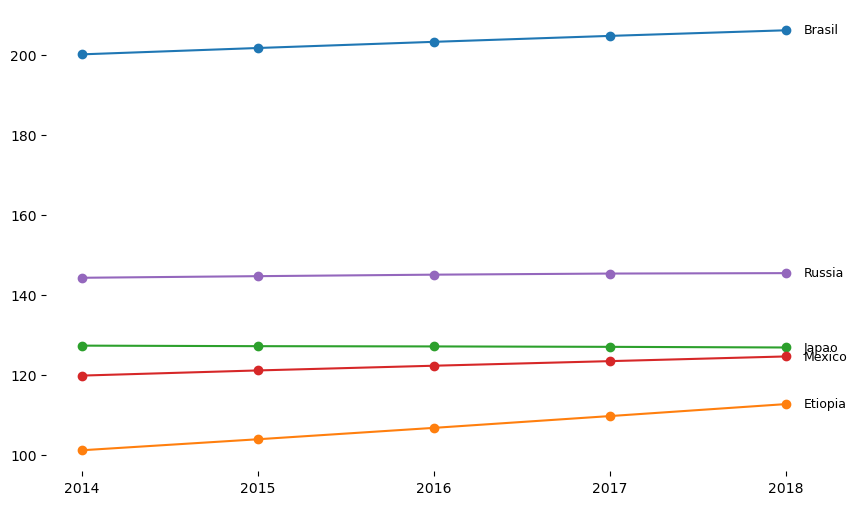

In [5]:
# Criar o gráfico de linhas: um plot (uma linha) por país
plt.figure(figsize=(10, 6))
for _, linha in data_evolucao.iterrows():
    plt.plot(anos, linha[anos], marker='o', zorder=3)
    # Anotar o nome do país ao final de cada curva, à direita
    plt.text(len(anos) - 1 + 0.1, linha[anos[-1]], linha['Pais'], va='center', fontsize=9)

# Formatar o eixo y para mostrar em escala de 10^6 sem decimais
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y / 1e6)}'))

# Remover o frame externo do gráfico
for lado in ('top', 'right', 'bottom', 'left'):
    plt.gca().spines[lado].set_visible(False)

# Mostrar o gráfico
plt.show()

Há duas situações em que prefiro usar gráficos de barras em vez de gráficos de linha para mostrar mudanças ao longo do tempo. Primeiro, quando há poucos pontos de dados — por exemplo, apenas cinco anos —, a maior quantidade de tinta nas cinco barras confere ao gráfico mais peso visual. Segundo, quando trabalho com intervalos de tempo discretos (e poucas observações), como o primeiro trimestre do ano.

O excesso de elementos visuais é o principal aspecto a considerar ao avaliar se um gráfico de barras pareadas é a abordagem adequada. Com muitas barras — e, especialmente, quando há mais de duas barras por categoria —, pode ser difícil para o leitor identificar padrões e determinar se a comparação mais importante ocorre entre as diferentes categorias ou dentro delas.

Ao avaliar se um gráfico de barras pareadas está visualmente sobrecarregado, confie em seus olhos e em sua intuição. Coloque-se no lugar dos leitores: tente imaginar para onde o olhar deles se voltará ao verem o gráfico pela primeira vez. Se houver muita informação, talvez seja necessário dividir os dados, utilizar outro tipo de gráfico ou adotar uma abordagem de múltiplos pequenos gráficos (*small multiples*).